# Overview
This notebook computes fluid dynamics quantities (given parameters of nitrogen gas and tubing) including:
- flow impedance using Darcy–Weisbach equation

$$Z = f \cdot \frac{L}{D} \cdot \frac{V^2}{2g}$$
$$\Delta P = \rho g Z = f \cdot \frac{L}{D} \cdot \frac{\rho V^2}{2}$$

- flow rate using Hagen-Poiseuille equation, expressed as:
$$\Delta P = \frac{8\mu LQ}{\pi R^4}$$
$$Q = \frac{\Delta P \pi R^4}{8\mu L}$$
- Reynolds number
- 

These quantities are defined and described in the Methods section.

## Imports

In [79]:
# Plotting
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Vector math
import numpy as np

# Dataframes
import pandas as pd

# matplotlib plotting settings
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

## Nitrogen gas constants 

In [3]:
# Dynamic viscosity of nitrogen at STP
MU = 1.7e-5     # Pa*s, N/m^2 * s = kg/(m*s^2) * s

# Universal gas constant
GAS_CONSTANT = 8.314        # J/(mol*K)

# Molar volume of an ideal gas at STP
MOLAR_VOLUME = 22.4         # L/mol

# Temperature, STP
TEMPERATURE_STP = 273.15    # K

# Density of nitrogen at STP
RHO_STP = 1.2506            # kg/m^3

# Specific gravity of nitrogen (relative to air)
SPECIFIC_GRAVITY = 0.967

# Ratio of specific heats for nitrogen
GAMMA = 1.4     

# Molar mass of nitrogen gas
MOLAR_MASS_N2 = 28.0134    # g/mol

# Gas constant for nitrogen (R = R_universal / M) in J/(kg*K)
R_N2 = GAS_CONSTANT / (MOLAR_MASS_N2 / 1000)  # Convert g/mol to kg/mol

## Unit conversions

In [35]:
# Inches to meters conversion factor
inch_to_meter = 0.0254

# Feet to meters conversion factor
ft_to_m = 0.3048

# Cubic meters per second to liters per minute conversion factor
m3s_to_lpm = 60000

# PSI to Pascals conversion factor
psi_to_pa = 6894.76

# SCFH to liters per minute conversion factor
scfh_to_lpm = 28.3168 / 60

## Methods

In [ ]:
# Cross sectional area
def calculate_cross_sectional_area(d):
    r = d / 2
    A = np.pi * r**2
    return A

# Hagen-Poiseuille equation
# Describes the pressure drop across a cylindrical tube of constant cross-sectional area for laminar flow.
def calculate_hagen_poiseuille_flow(dp, r, l, mu):
    """
    Parameters:
        dp: Pressure drop across the tube (Pa)
        r: Radius of the tube (m)   
        l: Length of the tube (m)
        mu: Dynamic viscosity of the fluid (Pa*s)
    Returns:
        flow_rate: Volumetric flow rate (m^3/s)
        impedance: Hydraulic impedance (Pa*s/m^3)

    Governing relation for flow is flow Q * impedance Z = pressure drop dP
    Here, impedance Z = (8 * mu * l) / (pi * r^4) for laminar flow in a cylindrical tube.
    """
    impedance = (8 * mu * l) / (np.pi * r**4)   # Pa*s/m^3
    flow_rate = dp / impedance                  # m^3/s
    return flow_rate, impedance

# Same relation as above but the input is flow so that dp is returned.
def calculate_hagen_poiseuille_dp(flow, r, l, mu):
    """
    Parameters:
        flow: Volumetric flow rate (m^3/s)
        r: Radius of the tube (m)   
        l: Length of the tube (m)
        mu: Dynamic viscosity of the fluid (Pa*s)
    Returns:
        dp: Pressure drop across the tube (Pa)
        impedance: Hydraulic impedance (Pa*s/m^3)

    Governing relation for flow is flow Q * impedance Z = pressure drop dP
    Here, impedance Z = (8 * mu * l) / (pi * r^4) for laminar flow in a cylindrical tube.
    """
    impedance = (8 * mu * l) / (np.pi * r**4)   # Pa*s/m^3
    dp = flow * impedance                  # m^3/s
    return dp, impedance

# Reynolds number (unitless)
# This predicts whether the flow is laminar or turbulent. For laminar flow, Re < 2300. Turbulent flow occurs when Re > 4000. The range in between is transitional.
def calculate_reynolds_number(rho, v, d, mu):
    """
    The reynolds number is unitless, ensure your passed quantities cancel units.

    Parameters:
        rho: Fluid density
        v: Flow velocity (speed)
        d: Characteristic length or dimension (e.g., pipe diameter)
        mu: Dynamic viscosity
        
        A typical quantity is also nu: Kinematic viscosity (nu = mu / rho)

    For convenience, returns: 
    (
        float: Reynolds number, 
        bool : flow type
    )

    Flow type:
        True if flow is laminar
        False if turbulent
        None if transitional
    """
    reynolds = (rho * v * d) / mu

    if reynolds < 2300:
        return reynolds, True
    elif reynolds > 4000:
        return reynolds, False
    else:
        return reynolds, None  # Transitional flow

# Blasius formula, giving the Darcy friction factor for turbulent flow in smooth pipes.
# Used to calculate the Darcy–Weisbach impedance
# Accurate for Reynolds number between 4000 and 100,000 (tubulent flow).
def calculate_friction_factor(reynolds):
    factor = 0.3164 * reynolds**(-0.25)
    return factor

# Darcy–Weisbach impedance: for incompressible fluid in a smooth cylindrical pipe.
def calculate_darcy_weisbach_impedance(
    friction_factor, 
    l, 
    d, 
    rho, 
    v, 
    Q
):
    """
    Parameters:
        friction_factor: Calculated using the Blasius equation for turbulent flow calculate_friction_factor()
        l: Length of the tube (m)
        d: Diameter of the tube (m)
        rho: Density of the fluid (kg/m^3)
        v: Flow velocity (m/s)
        Q: Volumetric flow rate (m^3/s)
    
    Returns:
        impedance: (Pa*s/m3)

    Note: expression is usually proportional to 1/g.
    But since Q = rho*g, we express as proportional to rho/Q so we can input a volumetric flow rate.
    Note also that a Pascal is N/m^2 = kg/(m*s^2)
    """
    impedance = friction_factor * (l / d) * (rho * v**2) / (2 * Q)    # Pa*s/m^3
    return impedance

# Calculates pressure increase rate for a given flow rate and volume, using ideal gas law.
def pressure_increase_rate(
    flow_slpm, 
    chamber_volume_m3, 
    temperature_K=TEMPERATURE_STP, 
    molar_volume_L_per_mol=MOLAR_VOLUME
):
    """
    Calculate pressure increase rate (dP/dt) in Pascals per minute in a fixed volume chamber.

    Parameters:
    - flow_slpm: flow rate at STP (litres per minute)
    - chamber_volume_m3: chamber volume in cubic meters
    - temperature_K: temperature in Kelvin (default 298 K)
    - molar_volume_L_per_mol: molar volume at STP in litres per mole (default 22.4 L/mol)

    Returns:
    - pressure increase rate in Pascals per minute

    Notes: From ideal gas law P = (n/V) * R * T, we can derive dP/dt = (R * T / V) * dn/dt, where dn/dt is the molar flow rate.
    """

    # flow rate to moles per minute
    dn_dt = flow_slpm / molar_volume_L_per_mol  # mol/min

    # dP/dt in Pascals per minute
    dP_dt = (GAS_CONSTANT * temperature_K / chamber_volume_m3) * dn_dt  # Pa/min

    return dP_dt

# Standard Sub-Critical Gas Flow Equation. Engineering formula used to size valves for gas flow.
def std_sub_critical_gas_flow(
    Cv, 
    P1_psi, 
    P2_psi, 
    T_C, 
    G=SPECIFIC_GRAVITY
):
    """
    Calculates nitrogen gas flow (std L/min) from Cv using the average pressure method.
    Assumes flow is sub-critical (not choked) and ideal gas behavior (gas not too compressed).

    Parameters:
    Cv       : Valve flow coefficient (unitless)
    P1_psi   : Inlet pressure (psia)
    P2_psi   : Outlet pressure (psia)
    T_C      : Temperature in Celsius
    G        : Specific gravity of gas (default for N2 = 0.967)

    Returns:
    Q_scfh : Flow rate in SCFH (standard cubic feet per hour)
    dP_dependence : The term dependent on pressure drop, useful for plotting flow vs pressure drop
    """
    # Convert temperature to Rankine (absolute scale for Fahrenheit)
    T_R = (T_C + 273.15) * 1.8

    # Calculate pressure drop and average pressure
    dP = P1_psi - P2_psi
    P_avg = (P1_psi + P2_psi) / 2

    if dP <= 0:
        return 0  # No flow if backpressure is too high

    # Return term dependent on dP for convenience in plotting flow vs pressure drop
    dP_dependence = 1360 * (dP / (G * T_R))**0.5 * P_avg**0.5

    # Flow in SCFH
    # Note: 1360 comes from Hours to seconds, Pounds to ounces, Gas constants, Standard atmospheric pressure constants.
    # Also, fluid velocity is proportional to the square root of the pressure drop over the average pressure.
    Q_scfh = Cv * dP_dependence

    return Q_scfh, dP_dependence

## Analysis

## Tubing impedances for turbulent flow

In [66]:
# Tube inner diameter and total length (ignoring bends, which would increase impedance)
diameter = 0.435 * inch_to_meter
radius = d/2
length = 18.55  # in meters
cross_area = calculate_cross_sectional_area(diameter) 

In [69]:
# For measured flow rates at set pressure drops, see if flow is turbulent or laminar based on Reynolds number, and compute impedance.

# Measured flow rates at set pressure drops (on radon purge system inlet side)
inlet_flow_rates = { # psig: slpm
    4: 38.4,
    8: 66.7,
    10: 79.0,
    14: 97.6
}

# Convert flow rates to m3/s
flow_rates_slpm = [rate for psig, rate in inlet_flow_rates.items()] 
flow_rates_m3ps = [rate / m3s_to_lpm for rate in flow_rates_slpm] 

# Calculate reynolds number for each flow rate
reynolds = []
velocities = []
dewar_pressures = list(inlet_flow_rates.keys())

for rate in flow_rates_m3ps:
    velocity = rate / cross_area
    velocities.append(velocity)
    reynolds.append(calculate_reynolds_number(RHO_STP, velocity, diameter, MU)[0])

# Pack data into a DataFrame for plotly
df = pd.DataFrame({
    'Dewar Pressure (psig)': dewar_pressures,
    'Flow Rate (L/min)': flow_rates_slpm,
    'Flow Rate (m3/s)': flow_rates_m3ps,
    'Velocity (m/s)': velocities,
    'Reynolds Number': reynolds
})

# Build the plot with colorbar indicating reynolds number
fig = px.scatter(
    df, 
    x='Dewar Pressure (psig)', 
    y='Flow Rate (L/min)',
    color='Reynolds Number',      # Automatically colors the markers & adds the colorbar
    color_continuous_scale='viridis',
    title=(
        f'Inlet Flow Rate and Reynolds Number vs. Dewar Pressure<br>'
        f'<sup>Reynolds number calculated for {diameter / inch_to_meter:.3f} in ID tubing</sup>'
    )
)
custom_hover = (
    "<b>Dewar Pressure:</b> %{x:.2f} psig<br>" +
    "<b>Flow Rate:</b> %{y:.2f} L/min<br>" +
    "<b>Reynolds Number:</b> %{marker.color:.1e}<br>" +
    "<extra></extra>"
)
fig.update_traces(hovertemplate=custom_hover)
fig.update_layout(template='plotly_white')
fig.write_html(f"measured_inlet_lpm_vs_psig_for_{diameter / inch_to_meter:.3f}in.html")
fig.show()

In [71]:
# Based on the plot above, clearly all flow measured was turbulent.

# Impedance for turbulent flow must be calculated using darcy-weisbach (hagen-poiseuille is for laminar flow)
# Calculate the friction factors and send measurements into darcy-weisbach
# Use .apply() for the single-variable function
df["Friction factor"] = df["Reynolds Number"].apply(calculate_friction_factor)

# Use .apply() with a lambda function for multi-variable equations
# (axis=1 tells Pandas to pass the entire row to the lambda expression)
df["Impedance (Pa*s/m3)"] = df.apply(
    lambda row: calculate_darcy_weisbach_impedance(
        row["Friction factor"], 
        length, 
        diameter, 
        RHO_STP, 
        row["Velocity (m/s)"], 
        row["Flow Rate (m3/s)"]
    ), 
    axis=1
)

df["Pressure drop (PSI)"] = (df["Flow Rate (m3/s)"] * df["Impedance (Pa*s/m3)"]) / psi_to_pa

df["Effective impedance (Pa*s/m3)"] = (df["Dewar Pressure (psig)"] * psi_to_pa) / df["Flow Rate (m3/s)"]

# Plot impedance vs flow rate
# Sort by x-axis so connecting line doesnt zig zag in original order of dataframe entries
df_sorted = df.sort_values(by='Flow Rate (L/min)')
fig = px.scatter(
    df_sorted, 
    x='Flow Rate (L/min)', 
    y='Pressure drop (PSI)',
    color='Impedance (Pa*s/m3)',
    hover_data = ["Friction factor", "Effective impedance (Pa*s/m3)"],
    title=(
        f'Pressure Drop and Impedance vs. Turbulent Flow<br>'
        f'<sup>For tube: Length ({length:.2f} m), Inner diameter ({diameter / inch_to_meter} in)</sup>'
    )
)
custom_hover = (
    "<b>Flow Rate:</b> %{x:.2f} L/min<br>" +
    "<b>Pressure Drop:</b> %{y:.2f} PSI<br>" +
    "<b>Impedance:</b> %{marker.color:.2e} Pa*s/m3<br>" + # Used scientific notation :.2e for impedance if numbers are huge
    "<b>Friction Factor:</b> %{customdata[0]:.4f}<br>" +  # 4 decimals for friction factor
    "<b>Effective Impedance:</b> %{customdata[1]:.2e} Pa*s/m3<br>" +
    "<extra></extra>" # This empty extra tag removes the default secondary hover box (trace name)
)
fig.update_traces(
    mode='lines+markers', 
    marker_size=10,
    hovertemplate=custom_hover
)
fig.update_layout(template='plotly_white')
fig.write_html(f"dp_and_z_for_{length:.2f}m_{diameter / inch_to_meter}in_tube.html")
fig.show()

## Pressure changes in a volume for varying input flow rate

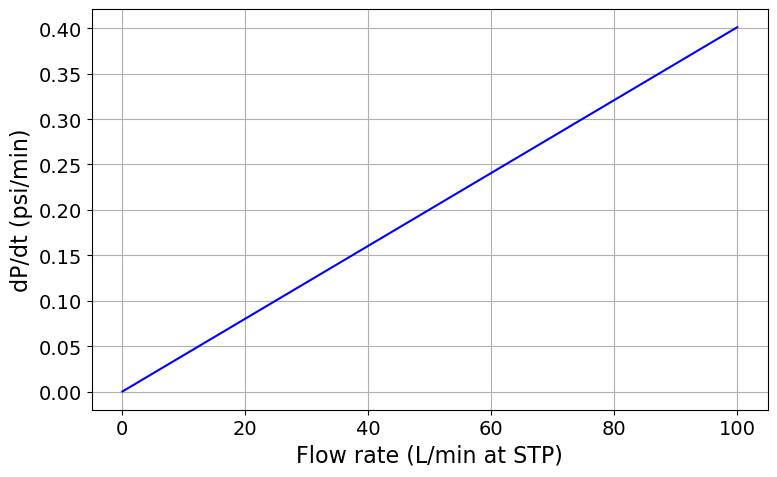

In [ ]:
# Plotting pressure increase rate vs flow rate for a fixed volume chamber, using ideal gas law.
# Relates possible input flow rates from the purge system Flow Controller to the pressure increase rate in the radon barrier volume.
# Note: the flow rate of the flow controller will be changing in response to changing differential pressure. But this plot allows us to see directly what the pressure increase rate would be for the maximum flow rate (once measured) and for the normal operation case where dP is steady (flow will be constant at some measured value).

# Parameters
volume = 4            # chamber volume in cubic meters
temperature = 298     # room temperature in Kelvin

# Flow rates
flow_rates = np.linspace(0, 100, 100)

# Calculate pressure increase rates for all flow rates
pressure_rates = [
    pressure_increase_rate(fr, volume, temperature_K=temperature) / psi_to_pa \
    for fr in flow_rates
]

# Plotting
plt.figure(figsize=(8,5))
plt.plot(flow_rates, pressure_rates, linestyle='-', color='b')
plt.xlabel("Flow rate (L/min at STP)", fontsize=16)
plt.ylabel("dP/dt (psi/min)", fontsize=16)
plt.grid(True)
plt.tight_layout()

plt.savefig("dp_rate_vs_inlet_flow.png")

plt.show()

## What differential pressure rates cause the check valve to open?
This analysis answers the question prompted by the previous plot. 

We have measured that at 10 psig, our flow controller flows at ~80 SLPM. According to the above plot, this is equal to ~0.33 psi/min inside the barrier volume, ignoring intake through the exhaust tube in the event of underpressure, when we would see the flow rate rise possibly to this maximum.

Assuming that the flow controller will adjust to maximum flow if ambient pressure rises, what differential pressures occuring over what intervals of time will our flow controller not be able to equilibrate pressure in the barrier volume, causing the intake check valve to open (cracking pressure ~0.1 psid)?

In [94]:
# Parameters
max_flow = 80   # SLPM
max_dp_rate = pressure_increase_rate(max_flow, volume, temperature_K=temperature) / psi_to_pa   # PSI/min
cracking_pressure = 0.1     # PSID
initial_dp = 0.001          # PSID

# What ambient pressure increases would cause the check valve to open considering the flow rate in?

# Time intervals over which the ambient pressure increase occurs (relative pressure in volume drops)
pressure_change_intervals = []    # seconds

# For a pressure drop, compute the time needed to reach -0.1 psid in the volume if there is inlet flow of 80 SLPM
ambient_drops = np.linspace(0.0, 0.5, 100)     # psid

def time_for_check_valve_actuation(
    ambient_pressure_change, 
    max_dp_rate, 
    cracking_pressure, 
    setpoint_dp
):
    """
    Calculates the maximum allowed time interval (in minutes) for an ambient pressure change to occur. If the change happens in LESS than this time, the controller fails and the valve opens.

    Parameters:
        ambient_pressure_change: magnitude of pressure increase in atmosphere, creating an underpressure in the volume
        max_dp_rate: rate in psi/min that is flowed into the volume
        cracking_pressure: magnitude of differential pressure that check valve opens
        setpoint_dp: initial differential pressure of the volume
    """
    # The amount of pressure drop in the barrier starting from the initial barrier pressure to reach the check valve cracking pressure
    dp_headroom = cracking_pressure + setpoint_dp

    # Condition 1: If the ambient spike doesn't even exceed our headroom, it can happen instantly (0 seconds) and the valve STILL won't open.
    if ambient_pressure_change <= dp_headroom:
        return 0.0

    # Condition 2: If the change is larger than headroom, the controller buys us time, but cannot fully stop it if it happens too fast.
    time_interval_minutes = (
        ambient_pressure_change - dp_headroom
    ) / max_dp_rate

    return time_interval_minutes

# Compute the intervals (in seconds for higher resolution if desired)
intervals_seconds = [
    time_for_check_valve_actuation(dp, max_dp_rate, cracking_pressure, initial_dp)
    * 60.0
    for dp in ambient_drops
]

In [ ]:
# Plot it
x_data = np.array(intervals_seconds)
y_data = np.array(ambient_drops)

# Create the figure
fig = go.Figure()

# Add an invisible upper boundary line at the top of the plot to bound the fill area
fig.add_trace(
    go.Scatter(
        x=x_data,
        y=np.ones_like(y_data) * max(y_data),  # Ceiling of the plot
        mode="lines",
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip",
    )
)

# Add the actual threshold line and fill the area BETWEEN the ceiling and this line
fig.add_trace(
    go.Scatter(
        x=x_data,
        y=y_data,
        mode="lines",
        line=dict(color="crimson", width=3),
        name=f"Valve Cracking Threshold ({max_dp_rate:.2f} psi/min)",
        fill="tonexty",  # Shades the region ABOVE the curve (between trace 0 and 1)
        fillcolor="rgba(220, 53, 69, 0.2)",  # Semi-transparent red
        hovertemplate="<b>Min Safe Interval:</b> %{x:.1f} s<br><b>Pressure Rise:</b> %{y:.2f} psi<extra></extra>",
    )
)

# Update layout and styling
fig.update_layout(
    title=dict(
        text=(
            f"<b>Intake Check Valve Actuation Region</b>"
            f"<br><sup>The shaded region represents where the flow controller is overwhelmed by the underpressure event</sup>"
            f"<br><sup>Ignores intake through exhaust (conservative) | Assumes instantaneous max {max_flow} SLPM flow rate (optimistic)</sup>"
        ),
        font=dict(size=16),
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(
        title="Time Interval of Ambient Pressure Rise (s)",
        gridcolor="rgba(200, 200, 200, 0.2)",
        zeroline=False,
    ),
    yaxis=dict(
        title="Ambient Pressure Rise Magnitude (psi)",
        gridcolor="rgba(200, 200, 200, 0.2)",
        zeroline=False,
        range=[0, max(y_data)],
    ),
    annotations=[
        dict(
            x=max(x_data) * 0.2,
            y=max(y_data) * 0.7,
            text="<b>VALVE OPENS</b><br>(Disturbance happens too fast)",
            showarrow=False,
            font=dict(color="rgba(180, 40, 50, 1)", size=14),
        ),
        dict(
            x=max(x_data) * 0.7,
            y=max(y_data) * 0.4,
            text="<b>VALVE STAYS CLOSED</b><br>(Controller successfully compensates)",
            showarrow=False,
            font=dict(color="darkgreen", size=14),
        ),
    ],
    template="plotly_white",
    width=800,
    height=500,
    showlegend=True,
    legend=dict(yanchor="bottom", y=0.01, xanchor="right", x=0.99),
)

# Save and display the plot
fig.write_html(f"intake_valve_crack_conditions_for_{max_flow}slpm_inlet_flow.html")
fig.show()

## Frequency of inlet check valve opening
Based on the previous plot, we have identified a set of barrier underpressure conditions where the inlet check valve will open. Since the compensating inlet flow is assumed to be instantaneous which is not conservative, we should show how often the check valve opens over a variety of max flow rates.

To do this, we will use real ambient pressure data. 

For each possible max inlet flow rate which defines the check valve cracking threshold, we will filter the pressure data by dp/dt > this threshold, and make sure to only count underpressure events that take place over multiple time steps once.

More significantly than the frequency of opening is the total time the check valve is open over the entire data period.

Plot the fraction of the data the check valve is open vs max inlet flow rate.

In [123]:
# Load the data into a dataframe
cavern_df = pd.read_csv("local_data/atmPressure-CUTE-csv.csv")

In [127]:
# Standardize and sort data
cavern_df["datetime"] = pd.to_datetime(
    cavern_df["datetime"], format="'%Y-%m-%d %H:%M:%S'"
)
cavern_df = cavern_df.sort_values(by="datetime").drop_duplicates(subset=["datetime"])
cavern_df["pressure"] = pd.to_numeric(cavern_df["pressure"], errors="coerce")

# Identify the inherent time step of your dataset (e.g., 1 minute, 5 minutes)
# We find the most common time delta between existing consecutive rows
inferred_freq = cavern_df["datetime"].diff().mode()[0]

# Create a complete, unbroken datetime grid from start to finish
full_time_grid = pd.date_range(
    start=cavern_df["datetime"].min(), end=cavern_df["datetime"].max(), freq=inferred_freq
)

# Reindex the dataframe to inject the missing rows
cavern_df = (
    cavern_df.set_index("datetime")
    .reindex(full_time_grid)
    .rename_axis("datetime")
    .reset_index()
)

# Linearly interpolate the missing pressure values across the new gaps
# This prevents NaN propagation while keeping the physical transition smooth
cavern_df["pressure"] = cavern_df["pressure"].interpolate(method="linear")

# Convert pressure to PSI and compute derivatives safely
cavern_df["pressure_psi"] = cavern_df["pressure"] * 0.0145038

cavern_df["dP_psi"] = cavern_df["pressure_psi"].diff()
cavern_df["dt_min"] = cavern_df["datetime"].diff().dt.total_seconds() / 60
cavern_df["dp_dt_psi_per_min"] = cavern_df["dP_psi"] / cavern_df["dt_min"]

# Drop only the very first row (which is a natural NaN from the diff)
cavern_df_clean = cavern_df.dropna(
    subset=["dp_dt_psi_per_min", "dt_min"]
).reset_index(drop=True)

# Extract clean arrays for your state loops
dt_array = cavern_df_clean["dt_min"].to_numpy()
dp_dt_array = cavern_df_clean["dp_dt_psi_per_min"].to_numpy()
total_time = dt_array.sum()

In [128]:
# Define max inlet psi/min rates
undepressure_df = pd.DataFrame()
undepressure_df["Max flow rates (SLPM)"] = np.linspace(10, max_flow, 20)
undepressure_df["Max DP rates (PSI/min)"] = \
    undepressure_df.apply(
        lambda row: pressure_increase_rate(
            row["Max flow rates (SLPM)"], 
            volume, 
            temperature
        ) / psi_to_pa,
        axis=1
    )

In [138]:
# Prepare lists to store the final curves for plotting
fraction_conservative = []
distinct_events_cons = []
fraction_optimistic = []
distinct_events_opt = []

# Nominal baseline setpoint
setpoint_dp = 0.001 

# Valve characteristics
valve_cracking_pressure = -0.1  # psid
# 100 SLPM at -0.1 psi (cracking pressure)
base_valve_rate = pressure_increase_rate(100, volume, temperature) / psi_to_pa

# Extract arrays from dataframes for speed
dt_array = cavern_df_clean["dt_min"].to_numpy()
dp_dt_array = cavern_df_clean["dp_dt_psi_per_min"].to_numpy()

# Loop through each candidate controller capacity
for _, row in undepressure_df.iterrows():
    ctrl_rate = row["Max DP rates (PSI/min)"]
    
    # ----------------------------------------------------
    # 1. CONSERVATIVE BOUND (Pure Rate Filter)
    # ----------------------------------------------------
    is_overwhelmed = dp_dt_array > ctrl_rate
    time_open_cons = dt_array[is_overwhelmed].sum()
    fraction_conservative.append(time_open_cons / total_time)

    # Count Distinct Events
    # An event starts when it is overwhelmed now, but wasn't in the previous step
    event_starts_cons = is_overwhelmed & (~np.roll(is_overwhelmed, 1))

    # Negate the roll artifact of wrapping last element to index 0
    if len(is_overwhelmed) > 0:
        event_starts_cons[0] = is_overwhelmed[0]
    distinct_events_cons.append(event_starts_cons.sum())

    # ----------------------------------------------------
    # 2. OPTIMISTIC BOUND (Proportional Flow Simulation)
    # ----------------------------------------------------
    barrier_dp = setpoint_dp  # Reset internal volume pressure state
    valve_open_time = 0.0
    valve_status_history = np.zeros(len(dt_array), dtype=bool)
    
    for i in range(len(dt_array)):
        dt = dt_array[i]
        ambient_rate = dp_dt_array[i]
        
        # Check if we are past the cracking pressure
        if barrier_dp <= valve_cracking_pressure:
            # Delta past cracking pressure (e.g., if barrier is -0.12, delta is 0.02)
            delta_past_cracking = valve_cracking_pressure - barrier_dp
            
            # Flow rate is directly proportional to how far past cracking we are
            current_valve_rate = base_valve_rate * (1 + delta_past_cracking)
            
            valve_status_history[i] = True
            valve_open_time += dt
        else:
            current_valve_rate = 0.0
            
        # Update the state of the barrier volume pressure
        # (Internal goes up due to controller + valve, down due to ambient rise)
        barrier_dp += (ctrl_rate + current_valve_rate - ambient_rate) * dt
        
        # Upper clamp: Controller throttles down when it recovers back to setpoint
        if barrier_dp > setpoint_dp:
            barrier_dp = setpoint_dp

    fraction_optimistic.append(valve_open_time / total_time)
    
    # Count distinct simulated valve events
    event_starts = valve_status_history & (~np.roll(valve_status_history, 1))
    if len(valve_status_history) > 0:
        event_starts[0] = valve_status_history[0] 
    distinct_events_opt.append(event_starts.sum())

# Convert final lists to arrays for your Plotly graphing functions
fraction_time_open_conservative = np.array(fraction_conservative)
event_counts_cons = np.array(distinct_events_cons)
fraction_time_open_optimistic = np.array(fraction_optimistic)
event_counts_opt = np.array(distinct_events_opt)

In [146]:
# X-axis sweep array
x_flow_rates = undepressure_df["Max flow rates (SLPM)"].to_numpy()

# ----------------------------------------------------
# PLOT 1: TOTAL EXPOSURE TIME (%)
# ----------------------------------------------------
fig_time = go.Figure()

# Upper Bound - Conservative
fig_time.add_trace(
    go.Scatter(
        x=x_flow_rates,
        y=fraction_time_open_conservative * 100,
        mode="lines",
        line=dict(color="rgba(220, 53, 69, 0.4)", width=2, dash="dash"),
        name="Upper Bound (Inlet flow only)",
        hovertemplate="<b>Max Flow:</b> %{x:.1f} SLPM<br><b>Upper Limit:</b> %{y:.4f}%<extra></extra>",
    )
)

# Lower Bound - Optimistic (with Area Fill)
fig_time.add_trace(
    go.Scatter(
        x=x_flow_rates,
        y=fraction_time_open_optimistic * 100,
        mode="lines",
        line=dict(color="rgba(0, 123, 255, 0.8)", width=3),
        name="Lower Bound (With valve flow, neglecting impedance)",
        fill="tonexty",
        fillcolor="rgba(0, 123, 255, 0.1)",
        hovertemplate="<b>Max Flow:</b> %{x:.1f} SLPM<br><b>Lower Limit:</b> %{y:.4f}%<extra></extra>",
    )
)

fig_time.update_layout(
    title=dict(
        text=(
            "<b>Check Valve Total Exposure Time vs. Inlet Flow Capacity</b>"
            "<br><sup>The shaded region captures the calculated range of total valve open duration across the ~6 year cavern pressure time series.</sup>"
            "<br><sup>Ignores intake through exhaust | Assumes instant inlet flow | Assumes 100 SLPM valve flow at 0.1 psid and linear scaling with differential pressure</sup>"
        ),
        font=dict(size=14),
        x=0.5,
        xanchor="center",
        y=0.93,
    ),
    xaxis=dict(title="Maximum Inlet Flow Rate Capacity (SLPM)", gridcolor="rgba(200, 200, 200, 0.15)"),
    yaxis=dict(title="Total Fraction of Dataset Valve is Open (%)", gridcolor="rgba(200, 200, 200, 0.15)", zeroline=False),
    template="plotly_white",
    margin=dict(t=100, b=60, l=60, r=60),
    width=900,
    height=480,
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.95, xanchor="right", x=0.98)
)


# ----------------------------------------------------
# PLOT 2: DISTINCT ACTUATION EVENTS (Counts)
# ----------------------------------------------------
fig_events = go.Figure()

# Upper bound Event Counts
fig_events.add_trace(
    go.Scatter(
        x=x_flow_rates,
        y=event_counts_cons,
        mode="lines+markers",
        name="Upper bound (Inlet flow only)",
        line=dict(color="#d62728", width=2, dash="dash"),
        marker=dict(symbol="x", size=6),
        hovertemplate="<b>Max Flow:</b> %{x:.1f} SLPM<br><b>Cons. Events:</b> %{y}<extra></extra>",
    )
)

# Lower bound Event Counts
fig_events.add_trace(
    go.Scatter(
        x=x_flow_rates,
        y=event_counts_opt,
        mode="lines+markers",
        name="Lower bound (With valve flow, neglecting impedance)",
        line=dict(color="#2ca02c", width=2.5),
        marker=dict(symbol="circle", size=6),
        fill="tonexty",
        fillcolor="rgba(0, 123, 255, 0.1)",
        hovertemplate="<b>Max Flow:</b> %{x:.1f} SLPM<br><b>Sim. Events:</b> %{y}<extra></extra>",
    )
)

fig_events.update_layout(
    title=dict(
        text=(
            "<b>Valve Actuation Events vs. Inlet Flow Capacity</b>"
            "<br><sup>How often the intake valve opens across the ~6 year cavern pressure time series.</sup>"
            "<br><sup>Ignores intake through exhaust | Assumes instant inlet flow | Assumes 100 SLPM valve flow at 0.1 psid and linear scaling with differential pressure</sup>"
        ),
        font=dict(size=14),
        x=0.5,
        xanchor="center",
        y=0.93,
    ),
    xaxis=dict(title="Maximum Inlet Flow Rate Capacity (SLPM)", gridcolor="rgba(200, 200, 200, 0.15)"),
    yaxis=dict(title="Number of Distinct Opening Events", gridcolor="rgba(200, 200, 200, 0.15)", zeroline=False),
    template="plotly_white",
    margin=dict(t=100, b=60, l=60, r=60),
    width=900,
    height=480,
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.95, xanchor="right", x=0.98)
)

# Save
fig_time.write_html("underpressure_time_vs_inlet_flows.html")
fig_events.write_html("underpressure_freq_vs_inlet_flows.html")

# Render both separately
fig_time.show()
fig_events.show()

## Check valve flow coefficient

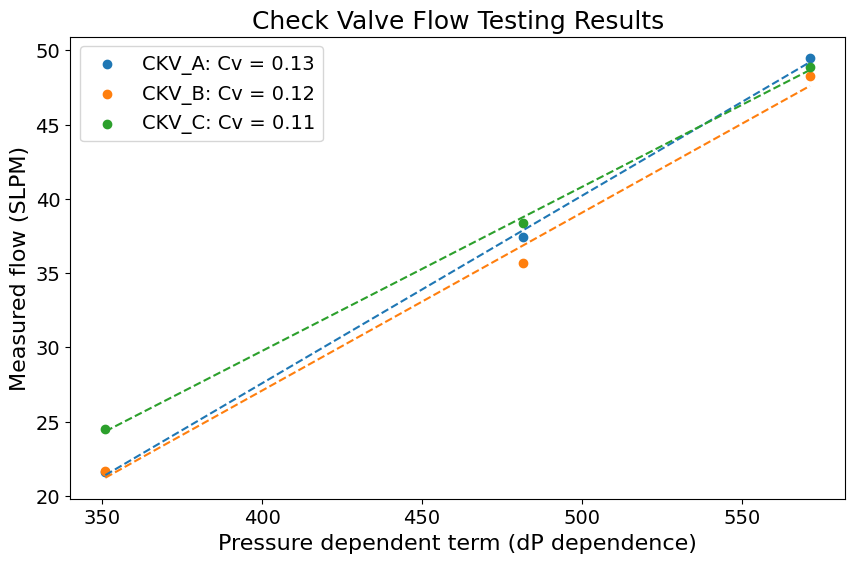

Computed flow (avg pressure method): 2588.681 std L/min


In [ ]:
# Calculate check valve flow coefficient based on results from check valve (CKV) flow testing.
# Results
set_dP = [2, 4, 6]

# We need the dP across the check valve only. Calculate the impedance and pressure drop across other connected tubes (SS and nylon inlet side tubing) to subtract these contributions away.


measured_flows = {      # SLPM
    "CKV_A": [21.6, 37.4, 49.5],
    "CKV_B": [21.7, 35.7, 48.3],
    "CKV_C": [24.5, 38.4, 48.9]
}

plt.figure(figsize=(10, 6))
for valve, flows in measured_flows.items():
    # Fit a line to the measured flows vs pressure terms caluclated by eqn for subcritical gas (using set dPs), to find the slope (Cv)
    dp_dependents = [std_sub_critical_gas_flow(Cv=1, P1_psi=18, P2_psi=18-dp, T_C=20)[1] for dp in set_dP]

    coeffs = np.polyfit(dp_dependents, flows, 1)  # Linear
    # print(f"coeffs: {coeffs}")
    Cv = coeffs[0]

    # Plot the measured flows vs the pressure dependent term, and the fitted line.
    plt.scatter(dp_dependents, flows, marker='o', label=f"{valve}: Cv = {Cv:.2f}")

    plt.plot(dp_dependents, np.poly1d(coeffs)(dp_dependents), linestyle='--')
plt.xlabel("Pressure dependent term (dP dependence)", fontsize=16)
plt.ylabel("Measured flow (SLPM)", fontsize=16)
plt.title("Check Valve Flow Testing Results", fontsize=18)
plt.legend()
plt.show()

# Compare measured to predicted using extracted Cv values for each valve.
# Calculate how much max flow you get out of the check valve with flow coefficient for a given differential pressure
# Example calculation: flow rate at cracking pressure = P2_psi - P1_psi = 0.1 psi. 
# For a pressure drop from testing flow rate with dewar set psig, P1 is atmospheric pressure (14.7 psi) and P2 is dewar pressure.
flow, dp_dependent_term = std_sub_critical_gas_flow(Cv=68, P1_psi=18, P2_psi=17.9, T_C=20)
flow_lpm = flow * scfh_to_lpm

print(f"Computed flow (avg pressure method): {flow_lpm:.3f} std L/min")

## Check valve flow rate
Plot the maximum flow rate through a check valve for varying differential pressures across it.
Dependent variables include:
- parameters for nitrogen gas
- parameters of the tube in the path of the check valve (diameter and length)
- 

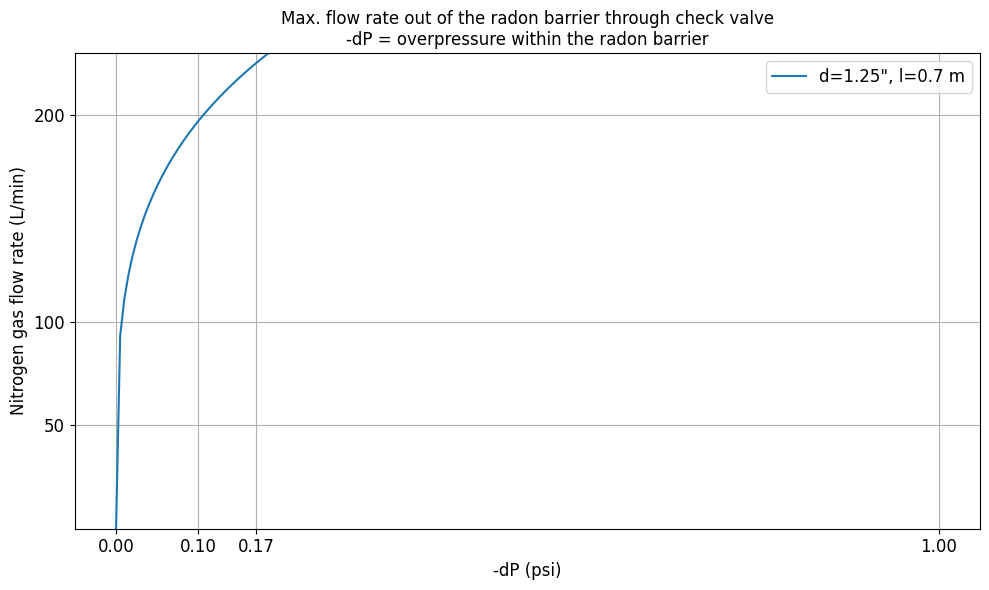

In [ ]:
# Nitrogen at STP
eta = 1.7e-5   # Pa·s
rho = 1.125     # kg/m³

# dP
dp_psi_array = np.linspace(0, 1, 200)
dp_array = dp_psi_array * 6894.6  # Convert to Pa

# Tube diameters in inches
diameters_inches = [0.5, 0.75, 1, 1.25, 1.5]
diameters_meters = [d * 0.0254 for d in diameters_inches]  # Convert to meters

# Tube lengths in meters
length_list = [0.7]  

plt.figure(figsize=(10, 6))

for l_fixed in length_list:
    for d_m in diameters_meters:
        r_fixed = d_m / 2
        A = np.pi * r_fixed**2

        Q_out_lpm = []
        Re_at_max_flow = None

        for dp_psi, dp in zip(dp_psi_array, dp_array):
            # Use Poiseuille-Hagen equation for Re < 4000 and Darcy-Weisbach for Re > 4000
            Z_poiseuille = (8 * eta * l_fixed) / (np.pi * r_fixed**4)
            Q_poiseuille = dp / Z_poiseuille
            v = Q_poiseuille / A
            Re = (rho * v * d_fixed) / eta

            if Re <= 4000:
                Q_used = Q_poiseuille
            else:
                f = 0.3164 * Re**(-0.25)
                Z_darcy = f * (l_fixed / d_fixed) * (rho * v**2) / (2 * Q_poiseuille)
                Q_used = dp / Z_darcy

            Q_lpm = Q_used * 60 * 1000  # Convert m³/s to L/min
            Q_out_lpm.append(Q_lpm)

            # Optional print for debugging
            #print(f'dP = {dp_psi:.2f} psi -> Flow rate = {Q_lpm:.2f} L/min')

            # Reynolds number for max ΔP
            if dp == dp_array[-1]:
                v_max = Q_used / A
                Re_at_max_flow = (rho * v_max * d_fixed) / eta

        label = f'd={d_inch} in, l={l_fixed} m'
        plt.plot(dp_psi_array, Q_out_lpm, label=label)

plt.xlabel("-dP (psi)", fontsize=12)
plt.ylabel("Nitrogen gas flow rate (L/min)", fontsize=12)
plt.title("Max. flow rate out of the radon barrier through check valve\n-dP = overpressure within the radon barrier", fontsize=12)
plt.xticks([0,0.1,0.17,1], fontsize=12)
plt.yticks([50,100,200,300,400])
plt.yticks(fontsize=12)
plt.ylim(0,230)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()